# Motor Sound Classification — Inference & Data Visualization

This notebook loads trained model checkpoints and runs inference on audio files,  
with rich visualizations for waveforms, mel spectrograms, prediction confidence,  
confusion matrices, per-class metrics, and cross-model comparisons.

**Models supported:** GRU · LSTM · LSTM-GRU · AudioModel (Rotational PE) · AudioModel (Sinusoidal PE) · AudioModel (Relative PE)

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import math, os, copy
from glob import glob
from pathlib import Path

import torch
import torch.nn as nn
import torchaudio

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

print("PyTorch:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.10.0+cu128
Device: cuda


In [2]:
class config:
    # ── Data ──────────────────────────────────────────────────────────────
    base_audio_dir = "/kaggle/input/datasets/pythonafroz/electrical-motor-operational-state-sound-data/IDMT-ISA-ELECTRIC-ENGINE"

    # ── Audio processing ──────────────────────────────────────────────────
    n_fft         = 1024
    hop_length    = 1024 // 2
    n_mels        = 80
    sampling_rate = 16_000

    # ── Model architecture ────────────────────────────────────────────────
    n_class           = 3
    batch_size        = 5
    input_size        = 80

    n_lstm_layer      = 2
    lstm_hidden_size  = 512

    n_gru_layer       = 2
    gru_hidden_size   = 512

    n_lstm_gru_layer      = 2
    lstm_gru_hidden_size  = 512

    in_channel   = 1
    embed_dim    = 1024
    patch_size   = 16
    num_head     = 16
    n_blocks     = 12
    max_seq_len  = 2048

    # ── Checkpoint paths ──────────────────────────────────────────────────
    # Update these paths to wherever your .pt files are saved
    checkpoint_dir = "/kaggle/input/datasets/edifonjimmy/motor-models"   # current directory by default

    # ── Inference device ──────────────────────────────────────────────────
    device = "cuda" if torch.cuda.is_available() else "cpu"

# Class labels — update if your dataset uses different names
CLASS_NAMES = ['engine1_good', 'engine2_broken', 'engine3_heavyload']   # alphabetical order matches LabelEncoder
print("Classes:", CLASS_NAMES)

Classes: ['engine1_good', 'engine2_broken', 'engine3_heavyload']


## 2. Model Definitions

Identical architectures to the training notebook so checkpoints load cleanly.

In [3]:
# ── GRU ───────────────────────────────────────────────────────────────────
class GRUModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(config.n_gru_layer):
            inp = config.input_size if i == 0 else 2 * config.gru_hidden_size
            self.layers.append(nn.GRU(inp, config.gru_hidden_size, batch_first=True, bidirectional=True))
        self.ln       = nn.LayerNorm(2 * config.gru_hidden_size)
        self.out_proj = nn.Linear(2 * config.gru_hidden_size, config.n_class)

    @property
    def name(self): return "gru_model"

    def forward(self, x):
        x = x.squeeze(1)
        for layer in self.layers:
            x, _ = layer(x)
            x = self.ln(x)
        return self.out_proj(x)[:, -1, :]


# ── LSTM ──────────────────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(config.n_lstm_layer):
            inp = config.input_size if i == 0 else 2 * config.lstm_hidden_size
            self.layers.append(nn.LSTM(inp, config.lstm_hidden_size, batch_first=True, bidirectional=True))
        self.ln       = nn.LayerNorm(2 * config.lstm_hidden_size)
        self.out_proj = nn.Linear(2 * config.lstm_hidden_size, config.n_class)

    @property
    def name(self): return "lstm_model"

    def forward(self, x):
        x = x.squeeze(1)
        for layer in self.layers:
            x, _ = layer(x)
            x = self.ln(x)
        return self.out_proj(x)[:, -1, :]


# ── LSTM-GRU ──────────────────────────────────────────────────────────────
class LSTMGRUModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(config.n_lstm_gru_layer):
            inp = config.input_size if i == 0 else 2 * config.lstm_gru_hidden_size
            self.layers.append(nn.LSTM(inp, config.lstm_gru_hidden_size, batch_first=True, bidirectional=True))
            self.layers.append(nn.GRU(2 * config.lstm_gru_hidden_size, config.lstm_gru_hidden_size, batch_first=True, bidirectional=True))
        self.ln       = nn.LayerNorm(2 * config.lstm_gru_hidden_size)
        self.out_proj = nn.Linear(2 * config.lstm_gru_hidden_size, config.n_class)

    @property
    def name(self): return "lstm_gru_model"

    def forward(self, x):
        x = x.squeeze(1)
        for layer in self.layers:
            x, _ = layer(x)
            x = self.ln(x)
        return self.out_proj(x)[:, -1, :]


# ── Positional Encodings ──────────────────────────────────────────────────
class RotationalPE(nn.Module):
    def __init__(self, config):
        super().__init__()
        d_k     = config.embed_dim // config.num_head
        pos     = torch.arange(0, config.max_seq_len).float().unsqueeze(1)
        inv_freq = torch.exp((torch.arange(0, d_k, 2) * -math.log(10_000)) / d_k)
        mat_mul  = pos * inv_freq
        self.register_buffer("cos", mat_mul.cos())
        self.register_buffer("sin", mat_mul.sin())

    @property
    def name(self): return "rotational_pe"

    def forward(self, x):
        x1, x2 = x[..., 0::2], x[..., 1::2]
        seq = x.shape[-2]
        cos = self.cos[:seq][None, None, None, :, :]
        sin = self.sin[:seq][None, None, None, :, :]
        x_rot = torch.stack([x1 * cos - x2 * sin, x1 * sin + x2 * cos], dim=-1)
        return x_rot.flatten(-2)


class SinusoidalPE(nn.Module):
    def __init__(self, config):
        super().__init__()
        pe      = torch.zeros(config.max_seq_len, config.embed_dim).float()
        pos     = torch.arange(0, config.max_seq_len).float().unsqueeze(1)
        inv_freq = torch.exp((torch.arange(0, config.embed_dim, 2).float() * -math.log(10_000)) / config.embed_dim)
        mat_mul  = pos * inv_freq
        pe[:, 0::2] = torch.sin(mat_mul)
        pe[:, 1::2] = torch.cos(mat_mul)
        self.register_buffer("pe", pe.unsqueeze(0).unsqueeze(0))

    @property
    def name(self): return "sinusodal_pe"

    def forward(self, x): return x + self.pe[:, :, :x.shape[2], :]


class RelativePE(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.k     = config.max_seq_len - 1
        self.rel_emb = nn.Embedding(2 * self.k + 1, config.embed_dim)
        self.proj    = nn.Linear(config.embed_dim, config.num_head, bias=False)

    @property
    def name(self): return "relative_pe"

    def forward(self, x):
        seq = x.shape[-2]
        pos = torch.arange(seq, device=x.device)
        rel = (pos.unsqueeze(0) - pos.unsqueeze(1)).clamp(-self.k, self.k) + self.k
        bias = self.proj(self.rel_emb(rel)).permute(2, 0, 1)
        return bias.unsqueeze(0).unsqueeze(0)


# ── Attention-based AudioModel ────────────────────────────────────────────
class AudioAttentionBlock(nn.Module):
    def __init__(self, config, pe):
        super().__init__()
        self.pe  = pe
        self.config = config
        self.ln  = nn.LayerNorm(config.embed_dim)
        self.qkv = nn.Linear(config.embed_dim, 3 * config.embed_dim, bias=False)
        self.out_proj = nn.Linear(config.embed_dim, config.embed_dim)
        self.d_k = config.embed_dim // config.num_head

    def _qkv(self, x):
        B, C, seq, _ = x.shape
        qkv = self.qkv(x).view(B, C, seq, 3, self.config.num_head, self.d_k)
        return qkv.permute(0, 1, 3, 4, 2, 5).unbind(2)

    def forward(self, x):
        B, C, seq, _ = x.shape
        residual = x
        x = self.ln(x)
        if self.pe.name == "rotational_pe":
            q, k, v = self._qkv(x)
            q, k = self.pe(q), self.pe(k)
        elif self.pe.name == "sinusoidal_pe":
            x = self.pe(x)
            q, k, v = self._qkv(x)
        else:
            q, k, v = self._qkv(x)
            bias = self.pe(x)
        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)
        if self.pe.name == "relative_pe":
            attn = attn + bias
        attn = torch.nn.functional.softmax(attn, dim=-1)
        out  = attn @ v
        out  = out.transpose(2, 3).contiguous().view(B, C, seq, -1)
        return residual + self.out_proj(out)


class AudioEncoder(nn.Module):
    def __init__(self, config, pe):
        super().__init__()
        self.input_proj  = nn.Linear(config.n_mels, config.embed_dim, bias=False)
        self.attn_blocks = nn.ModuleList([AudioAttentionBlock(config, pe) for _ in range(config.n_blocks)])
        self.ln  = nn.LayerNorm(config.embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(config.embed_dim, 4 * config.embed_dim),
            nn.GELU(),
            nn.Linear(4 * config.embed_dim, config.embed_dim),
        )
        self.dropout = nn.Dropout()

    def forward(self, x):
        x = self.input_proj(x)
        for block in self.attn_blocks:
            x = block(x)
        shortcut = x
        return shortcut + self.mlp(self.ln(x))


class AudioModel(nn.Module):
    def __init__(self, config, pe):
        super().__init__()
        self.pe  = pe
        self.ae  = AudioEncoder(config, pe)
        self.out_proj = nn.Linear(config.embed_dim, config.n_class, bias=False)

    @property
    def name(self): return self.pe.name

    def forward(self, x):
        x = self.ae(x).squeeze(1)
        return self.out_proj(x).mean(dim=1)


print("Model classes defined.")

Model classes defined.


## 3. Checkpoint Loader

In [4]:
def build_all_models(cfg):
    """Instantiate all six model architectures."""
    return {
        "gru_model":      GRUModel(cfg),
        "lstm_model":     LSTMModel(cfg),
        "lstm_gru_model": LSTMGRUModel(cfg),
        "rotational_pe":  AudioModel(cfg, RotationalPE(cfg)),
        "sinusodal_pe":   AudioModel(cfg, SinusoidalPE(cfg)),
        "relative_pe":    AudioModel(cfg, RelativePE(cfg)),
    }


def load_checkpoints(models: dict, checkpoint_dir: str, device: str) -> dict:
    """
    Load .pt checkpoint files from `checkpoint_dir` into the model dict.
    Skips models whose checkpoint is not found and prints a warning.
    """
    loaded = {}
    for name, model in models.items():
        ckpt_path = os.path.join(checkpoint_dir, f"{name}.pt")
        if not os.path.exists(ckpt_path):
            print(f"  [SKIP]  {name}.pt not found in '{checkpoint_dir}'")
            continue
        state = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(state)
        model.to(device).eval()
        loaded[name] = model
        print(f"  [OK]    Loaded {ckpt_path}")
    return loaded


all_models  = build_all_models(config)
loaded_models = load_checkpoints(all_models, config.checkpoint_dir, config.device)
print(f"\nReady: {list(loaded_models.keys())}")

  [OK]    Loaded /kaggle/input/datasets/edifonjimmy/motor-models/gru_model.pt
  [OK]    Loaded /kaggle/input/datasets/edifonjimmy/motor-models/lstm_model.pt
  [OK]    Loaded /kaggle/input/datasets/edifonjimmy/motor-models/lstm_gru_model.pt
  [OK]    Loaded /kaggle/input/datasets/edifonjimmy/motor-models/rotational_pe.pt
  [OK]    Loaded /kaggle/input/datasets/edifonjimmy/motor-models/sinusodal_pe.pt
  [OK]    Loaded /kaggle/input/datasets/edifonjimmy/motor-models/relative_pe.pt

Ready: ['gru_model', 'lstm_model', 'lstm_gru_model', 'rotational_pe', 'sinusodal_pe', 'relative_pe']


## 4. Audio Preprocessing Utilities

In [5]:
mel_spec_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate = config.sampling_rate,
    n_fft       = config.n_fft,
    hop_length  = config.hop_length,
    n_mels      = config.n_mels,
)


def load_audio(path: str) -> tuple:
    """Load WAV, resample if needed, convert to mono. Returns (waveform, sr)."""
    wave, sr = torchaudio.load(path)
    if sr != config.sampling_rate:
        wave = torchaudio.transforms.Resample(sr, config.sampling_rate)(wave)
    if wave.shape[0] > 1:
        wave = wave.mean(dim=0, keepdim=True)
    return wave, config.sampling_rate


def audio_to_mel(wave: torch.Tensor) -> torch.Tensor:
    """Waveform → normalised log-mel spectrogram."""
    mel = torch.log1p(mel_spec_transform(wave))
    mel_norm = (mel - mel.mean()) / (mel.std() + 1e-1)
    return mel_norm.transpose(1, 2)          # (1, time_frame, n_mels)


def preprocess_for_inference(path: str, device: str) -> tuple:
    """Full pipeline: path → (mel_tensor_batched, waveform)."""
    wave, sr = load_audio(path)
    mel = audio_to_mel(wave)                 # (1, T, 80)
    x   = mel.unsqueeze(0).to(device)        # (1, 1, T, 80)
    return x, wave


print("Preprocessing utilities ready.")

Preprocessing utilities ready.


## 5. Single-file Inference

In [6]:
@torch.no_grad()
def predict_single(model: nn.Module, path: str, device: str, class_names: list) -> dict:
    """
    Run inference on one audio file.
    Returns dict with keys: path, predicted_label, confidence, probabilities, waveform, mel_tensor.
    """
    x, wave = preprocess_for_inference(path, device)
    logits  = model(x)                          # (1, n_class)
    probs   = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred_idx = probs.argmax()
    return {
        "path":            path,
        "predicted_label": class_names[pred_idx],
        "confidence":      float(probs[pred_idx]),
        "probabilities":   {c: float(p) for c, p in zip(class_names, probs)},
        "waveform":        wave,
        "mel_tensor":      x.squeeze(0).squeeze(0).cpu(),   # (T, 80)
    }


# ── Quick demo ────────────────────────────────────────────────────────────
# Point DEMO_AUDIO_PATH at any .wav file from the dataset
DEMO_AUDIO_PATH = "/kaggle/input/datasets/pythonafroz/electrical-motor-operational-state-sound-data/IDMT-ISA-ELECTRIC-ENGINE/test_cut/engine3_heavyload/atmo_low_19.wav"

if DEMO_AUDIO_PATH and loaded_models:
    first_model_name = list(loaded_models.keys())[0]
    result = predict_single(loaded_models[first_model_name], DEMO_AUDIO_PATH, config.device, CLASS_NAMES)
    print(f"File      : {Path(result['path']).name}")
    print(f"Prediction: {result['predicted_label']} ({result['confidence']:.1%})")
    for cls, prob in result['probabilities'].items():
        print(f"  {cls:>12s}: {prob:.4f}")
else:
    print("Set DEMO_AUDIO_PATH to a .wav file to run a quick inference demo.")

File      : atmo_low_19.wav
Prediction: engine3_heavyload (100.0%)
  engine1_good: 0.0000
  engine2_broken: 0.0000
  engine3_heavyload: 1.0000


## 6. Data Visualization

### 6.0 Audio Signal Visualizer — Waveform · Spectrogram · Mel Spectrogram

Three-panel inspection of a single audio file:
- **Waveform** — raw amplitude over time  
- **Spectrogram** — linear-frequency STFT power (dB)  
- **Mel Spectrogram** — log-power on the mel scale (the input your models see)

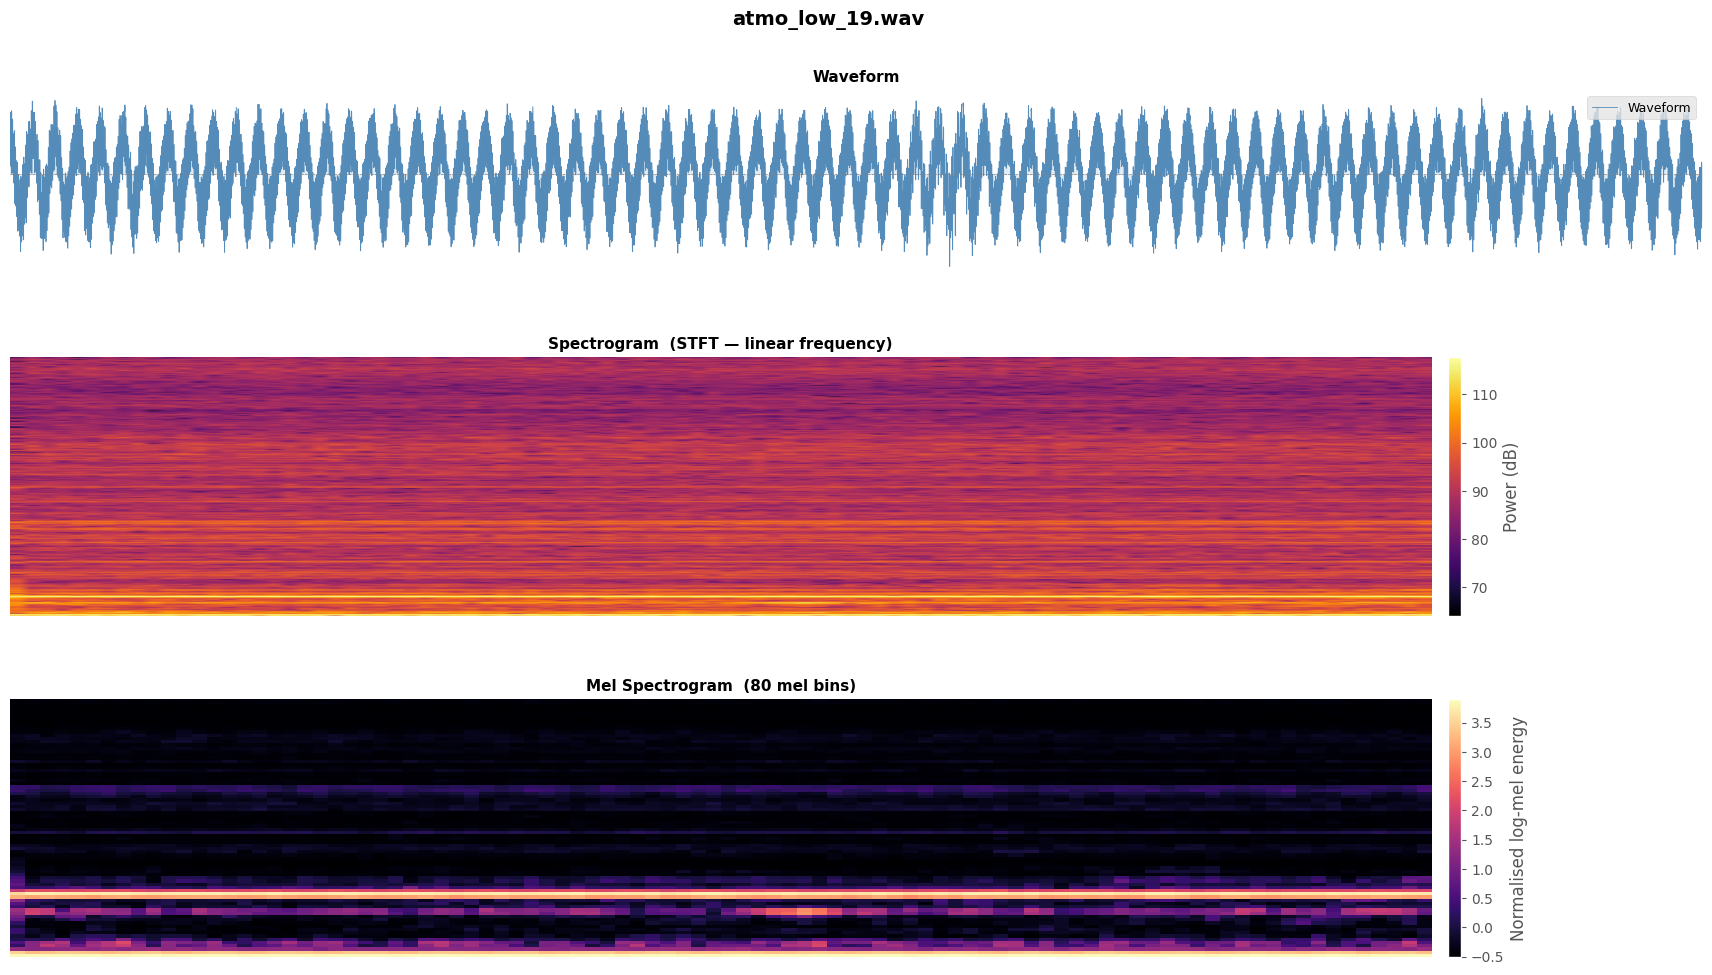

In [7]:
def plot_audio_full(path: str, true_label: str = "", figsize=(18, 10)):
    """
    Three-panel audio visualizer for a single WAV file.

    Panels
    ------
    Top    : Raw waveform with amplitude envelope shading
    Middle : Linear-frequency STFT spectrogram (power, dB scale)
    Bottom : Log-mel spectrogram (normalised, mel-bin scale)

    Parameters
    ----------
    path        : Path to a .wav audio file
    true_label  : Optional ground-truth label shown in the figure title
    figsize     : Matplotlib figure size
    """
    import torchaudio.functional as F

    # ── Load & resample ──────────────────────────────────────────────────
    wave, sr = load_audio(path)              # returns (1, N) mono tensor
    wave_np  = wave.squeeze().numpy()        # shape: (N,)
    t        = np.linspace(0, len(wave_np) / sr, len(wave_np))
    duration = len(wave_np) / sr

    # ── STFT spectrogram (linear frequency, power in dB) ─────────────────
    stft       = torch.stft(
        wave.squeeze(),
        n_fft      = config.n_fft,
        hop_length = config.hop_length,
        win_length = config.n_fft,
        window     = torch.hann_window(config.n_fft),
        return_complex = True,
    )                                        # (freq_bins, time_frames)
    power_db   = torchaudio.functional.amplitude_to_DB(
        stft.abs(), multiplier=10.0, amin=1e-10,
        db_multiplier=torch.log10(torch.tensor(1e-10)).item(),
        top_db=80.0,
    ).numpy()                               # (freq_bins, time_frames)

    # Frequency axis for STFT (0 … sr/2)
    freq_bins  = power_db.shape[0]
    freqs_khz  = np.linspace(0, sr / 2 / 1000, freq_bins)

    # ── Mel spectrogram (uses existing pipeline) ──────────────────────────
    mel_np     = audio_to_mel(wave).squeeze().numpy().T  # (n_mels, time_frames)

    # ── Figure layout ─────────────────────────────────────────────────────
    fig, axes  = plt.subplots(3, 1, figsize=figsize,
                               gridspec_kw={"height_ratios": [1, 1.4, 1.4]})
    title_suffix = f"  |  True label: {true_label}" if true_label else ""
    fig.suptitle(
        f"{Path(path).name}{title_suffix}",
        fontsize=14, fontweight="bold", y=1.01
    )

    # ── Panel 1 : Waveform ────────────────────────────────────────────────
    ax0 = axes[0]
    ax0.plot(t, wave_np, linewidth=0.6, color="steelblue", alpha=0.9, label="Waveform")
    ax0.fill_between(t, wave_np, alpha=0.15, color="steelblue")
    ax0.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    ax0.set_xlim(0, duration)
    ax0.set_xlabel("Time (s)")
    ax0.set_ylabel("Amplitude")
    ax0.set_title("Waveform", fontsize=11, fontweight="bold")
    ax0.legend(fontsize=9, loc="upper right")

    # ── Panel 2 : STFT Spectrogram ────────────────────────────────────────
    ax1 = axes[1]
    im1 = ax1.imshow(
        power_db,
        aspect="auto", origin="lower",
        extent=[0, duration, freqs_khz[0], freqs_khz[-1]],
        cmap="inferno"
    )
    plt.colorbar(im1, ax=ax1, label="Power (dB)", pad=0.01)
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Frequency (kHz)")
    ax1.set_title("Spectrogram  (STFT — linear frequency)", fontsize=11, fontweight="bold")

    # ── Panel 3 : Mel Spectrogram ─────────────────────────────────────────
    ax2 = axes[2]
    im2 = ax2.imshow(
        mel_np,
        aspect="auto", origin="lower",
        extent=[0, duration, 0, config.n_mels],
        cmap="magma"
    )
    plt.colorbar(im2, ax=ax2, label="Normalised log-mel energy", pad=0.01)
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Mel bin")
    ax2.set_title(f"Mel Spectrogram  ({config.n_mels} mel bins)", fontsize=11, fontweight="bold")

    plt.tight_layout()
    
    for ax in axes:
        ax.set_axis_off()

    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────
# Replace DEMO_AUDIO_PATH with any .wav file to visualise it.
# The true_label argument is optional — leave it empty if unknown.
#
#   plot_audio_full("/path/to/engine1_good/clip_001.wav",
#                   true_label="engine1_good")
#
if DEMO_AUDIO_PATH:
    plot_audio_full(DEMO_AUDIO_PATH, true_label="")
else:
    print("Set DEMO_AUDIO_PATH (cell above) to a .wav file, then re-run this cell.")

### 6.1 Waveform + Mel Spectrogram Inspector

In [8]:
def plot_audio_inspection(path: str, true_label: str = "", figsize=(14, 6)):
    """
    Two-panel view:
      Left  — raw waveform with amplitude envelope
      Right — log-mel spectrogram (80 mel bins × time)
    """
    wave, sr = load_audio(path)
    wave_np  = wave.squeeze().numpy()
    mel      = audio_to_mel(wave).squeeze().numpy().T  # (80, T)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    title_suffix = f" — True label: {true_label}" if true_label else ""
    fig.suptitle(f"{Path(path).name}{title_suffix}", fontsize=13, fontweight="bold")

    # Waveform
    t = np.linspace(0, len(wave_np) / sr, len(wave_np))
    axes[0].plot(t, wave_np, linewidth=0.5, color="steelblue", alpha=0.8, label="Waveform")
    axes[0].fill_between(t, wave_np, alpha=0.15, color="steelblue")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("Waveform")
    axes[0].legend(fontsize=9)

    # Mel spectrogram
    duration = len(wave_np) / sr
    im = axes[1].imshow(
        mel, aspect="auto", origin="lower",
        extent=[0, duration, 0, config.n_mels],
        cmap="magma"
    )
    plt.colorbar(im, ax=axes[1], label="Log-Mel energy")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Mel bin")
    axes[1].set_title("Log-Mel Spectrogram")

    plt.tight_layout()
    plt.show()

### 6.2 Prediction Confidence Bar Chart

In [9]:
def plot_confidence(result: dict, figsize=(7, 4)):
    """
    Horizontal bar chart showing per-class softmax probabilities
    for a single inference result.
    """
    labels = list(result["probabilities"].keys())
    probs  = list(result["probabilities"].values())
    colors = ["#2ecc71" if l == result["predicted_label"] else "#95a5a6" for l in labels]

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(labels, probs, color=colors, edgecolor="white", height=0.5)

    for bar, prob in zip(bars, probs):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{prob:.1%}", va="center", fontsize=11)

    ax.set_xlim(0, 1.12)
    ax.set_xlabel("Probability")
    ax.set_title(
        f"Prediction: {result['predicted_label']} ({result['confidence']:.1%})",
        fontsize=12, fontweight="bold"
    )
    ax.axvline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    plt.tight_layout()
    plt.show()

### 6.3 Batch Inference on a Directory

In [10]:
@torch.no_grad()
def batch_predict(model: nn.Module, wav_paths: list, device: str, class_names: list) -> pd.DataFrame:
    """
    Run inference on a list of WAV files.
    Returns a DataFrame with columns: path, true_label (from folder name), predicted_label,
    confidence, and one probability column per class.
    """
    rows = []
    for path in wav_paths:
        x, _ = preprocess_for_inference(path, device)
        logits = model(x)
        probs  = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
        pred   = class_names[probs.argmax()]
        true   = Path(path).parent.name
        row    = {"path": path, "true_label": true, "predicted_label": pred,
                  "confidence": float(probs.max())}
        row.update({f"prob_{c}": float(p) for c, p in zip(class_names, probs)})
        rows.append(row)
    return pd.DataFrame(rows)


# run batch inference ──────────────────────────────────────────
# Collect all test WAV files
TEST_DIR = os.path.join(config.base_audio_dir, "test_cut")

if os.path.isdir(TEST_DIR) and loaded_models:
    wav_files = glob(os.path.join(TEST_DIR, "**", "*.wav"), recursive=True)
    print(f"Found {len(wav_files)} test files.")

    # Run batch inference with the first available model
    first_name  = list(loaded_models.keys())[0]
    batch_df    = batch_predict(loaded_models[first_name], wav_files, config.device, CLASS_NAMES)
    print(batch_df.head())
else:
    print("TEST_DIR not found or no models loaded — using synthetic demo data for visualisation.")
    # Synthetic demo so all downstream cells still run
    rng = np.random.default_rng(42)
    n = 300
    true_labels = rng.choice(CLASS_NAMES, n)
    # Introduce realistic (not 100%) accuracy
    pred_labels = np.where(rng.random(n) > 0.15, true_labels,
                           rng.choice(CLASS_NAMES, n))
    confs = rng.uniform(0.6, 0.99, n)
    batch_df = pd.DataFrame({
        "path":            [f"demo_{i}.wav" for i in range(n)],
        "true_label":      true_labels,
        "predicted_label": pred_labels,
        "confidence":      confs,
        **{f"prob_{c}": rng.dirichlet([1]*3, n)[:, i] for i, c in enumerate(CLASS_NAMES)}
    })
    print(f"[Demo] Generated {n} synthetic inference rows.")

print(batch_df.shape)

Found 2021 test files.
                                                path         true_label  \
0  /kaggle/input/datasets/pythonafroz/electrical-...  engine3_heavyload   
1  /kaggle/input/datasets/pythonafroz/electrical-...  engine3_heavyload   
2  /kaggle/input/datasets/pythonafroz/electrical-...  engine3_heavyload   
3  /kaggle/input/datasets/pythonafroz/electrical-...  engine3_heavyload   
4  /kaggle/input/datasets/pythonafroz/electrical-...  engine3_heavyload   

     predicted_label  confidence  prob_engine1_good  prob_engine2_broken  \
0  engine3_heavyload    0.999967           0.000001             0.000032   
1  engine3_heavyload    0.999788           0.000022             0.000191   
2  engine3_heavyload    0.999978           0.000002             0.000020   
3  engine3_heavyload    0.999977           0.000003             0.000021   
4  engine3_heavyload    0.999967           0.000002             0.000031   

   prob_engine3_heavyload  
0                0.999967  
1            

In [11]:
batch_df["path"][0]

'/kaggle/input/datasets/pythonafroz/electrical-motor-operational-state-sound-data/IDMT-ISA-ELECTRIC-ENGINE/test_cut/engine3_heavyload/atmo_low_19.wav'

### 6.4 Confusion Matrix

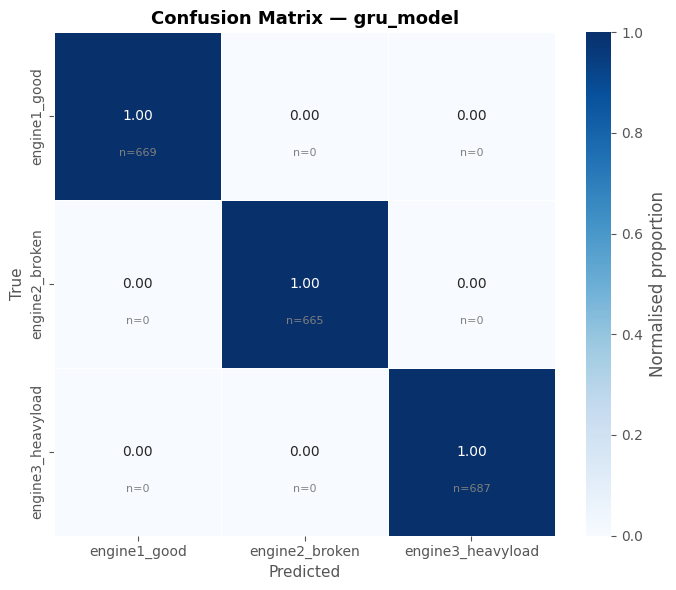

In [12]:
def plot_confusion_matrix(df: pd.DataFrame, class_names: list,
                          model_name: str = "", figsize=(7, 6)):
    cm = confusion_matrix(df["true_label"], df["predicted_label"], labels=class_names)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f",
        xticklabels=class_names, yticklabels=class_names,
        cmap="Blues", linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Normalised proportion"}, ax=ax
    )
    # Overlay raw counts
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j + 0.5, i + 0.72, f"n={cm[i,j]}",
                    ha="center", va="center", fontsize=8, color="grey")

    title = f"Confusion Matrix{' — ' + model_name if model_name else ''}"
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(batch_df, CLASS_NAMES, model_name=list(loaded_models.keys())[0] if loaded_models else "Demo")

In [13]:
set(batch_df["true_label"])

{'engine1_good', 'engine2_broken', 'engine3_heavyload'}

### 6.5 Per-Class Precision / Recall / F1

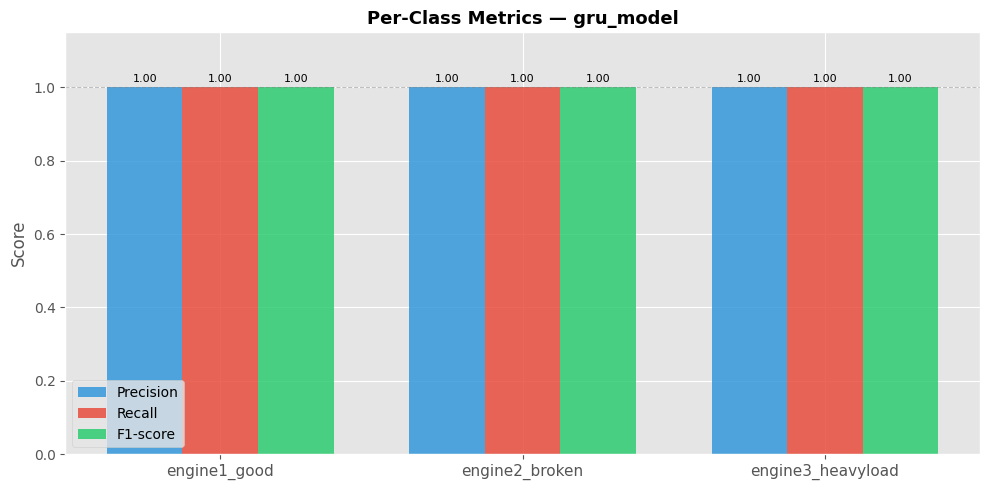

Macro — Precision: 1.0000  Recall: 1.0000  F1: 1.0000


In [14]:
def plot_per_class_metrics(df: pd.DataFrame, class_names: list,
                           model_name: str = "", figsize=(10, 5)):
    report = classification_report(
        df["true_label"], df["predicted_label"],
        labels=class_names, output_dict=True
    )
    metrics = ["precision", "recall", "f1-score"]
    data = {m: [report[c][m] for c in class_names] for m in metrics}

    x = np.arange(len(class_names))
    width = 0.25
    colours = ["#3498db", "#e74c3c", "#2ecc71"]

    fig, ax = plt.subplots(figsize=figsize)
    for i, (metric, colour) in enumerate(zip(metrics, colours)):
        bars = ax.bar(x + i * width, data[metric], width, label=metric.capitalize(), color=colour, alpha=0.85)
        for bar, val in zip(bars, data[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x + width)
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title(f"Per-Class Metrics{' — ' + model_name if model_name else ''}",
                 fontsize=13, fontweight="bold")
    ax.legend()
    ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
    plt.tight_layout()
    plt.show()

    overall = report["macro avg"]
    print(f"Macro — Precision: {overall['precision']:.4f}  "
          f"Recall: {overall['recall']:.4f}  F1: {overall['f1-score']:.4f}")


plot_per_class_metrics(batch_df, CLASS_NAMES,
                       model_name=list(loaded_models.keys())[0] if loaded_models else "Demo")

### 6.6 Confidence Distribution

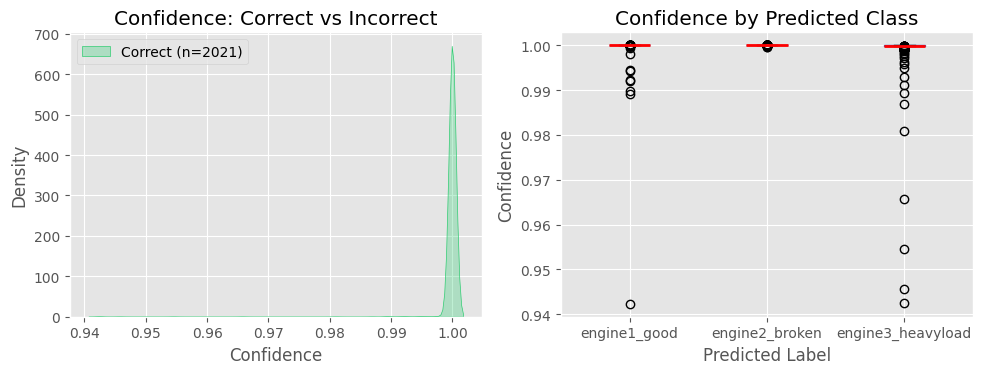

In [15]:
def plot_confidence_distribution(df: pd.DataFrame, class_names: list, figsize=(10, 4)):
    """
    KDE + rug plot of prediction confidence split by correct / incorrect predictions.
    """
    df = df.copy()
    df["correct"] = df["true_label"] == df["predicted_label"]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Overall correct vs incorrect
    for correct, label, colour in [(True, "Correct", "#2ecc71"), (False, "Incorrect", "#e74c3c")]:
        subset = df[df["correct"] == correct]["confidence"]
        if len(subset) > 1:
            sns.kdeplot(subset, ax=axes[0], label=f"{label} (n={len(subset)})",
                        fill=True, alpha=0.3, color=colour)
    axes[0].set_xlabel("Confidence")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Confidence: Correct vs Incorrect")
    axes[0].legend()

    # Per-class confidence box plot
    df.boxplot(column="confidence", by="predicted_label", ax=axes[1],
               patch_artist=True,
               boxprops=dict(facecolor="#3498db", color="navy", alpha=0.6),
               medianprops=dict(color="red", linewidth=2))
    axes[1].set_title("Confidence by Predicted Class")
    axes[1].set_xlabel("Predicted Label")
    axes[1].set_ylabel("Confidence")
    plt.suptitle("")

    plt.tight_layout()
    plt.show()


plot_confidence_distribution(batch_df, CLASS_NAMES)

### 6.7 Training History Comparison

If you saved training report CSVs (`model_name_history.csv`), load them here for  
cross-model learning curve comparison.

In [16]:
def load_training_histories(checkpoint_dir: str, model_names: list) -> dict:
    """
    Expects CSV files named `<model_name>_history.csv` with columns:
    epoch, train_total_loss, val_total_loss, train_total_accuracy, val_total_accuracy,
    train_total_f1score, val_total_f1score, train_total_precision, val_total_precision,
    train_total_recall, val_total_recall
    """
    histories = {}
    for name in model_names:
        csv_path = os.path.join(checkpoint_dir, f"{name}_history.csv")
        if os.path.exists(csv_path):
            histories[name] = pd.read_csv(csv_path)
            print(f"  [OK] Loaded history for {name}")
        else:
            print(f"  [SKIP] {csv_path} not found")
    return histories


def plot_training_comparison(histories: dict, metric: str = "loss", figsize=(13, 5)):
    """
    Plot train vs val `metric` curves for all models on shared axes.
    metric should be one of: loss, accuracy, f1score, precision, recall
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for ax, split in zip(axes, ["train", "val"]):
        for i, (name, df) in enumerate(histories.items()):
            col = f"{split}_total_{metric}"
            if col in df.columns:
                ax.plot(df["epoch"], df[col], label=name,
                        color=palette[i % len(palette)], linewidth=1.8)
        ax.set_title(f"{split.capitalize()} {metric.capitalize()}", fontsize=12)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.4)

    fig.suptitle(f"Model Comparison — {metric.capitalize()} over Epochs",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


MODEL_NAMES = ["gru_model", "lstm_model", "lstm_gru_model",
               "rotational_pe", "sinusodal_pe", "relative_pe"]

histories = load_training_histories(config.checkpoint_dir, MODEL_NAMES)

if histories:
    for m in ["loss", "accuracy", "f1score"]:
        plot_training_comparison(histories, metric=m)
else:
    print("No history CSVs found. Save training DataFrames as CSVs during training:")
    print("  gru_result.to_csv('gru_model_history.csv', index=False)")

  [SKIP] /kaggle/input/datasets/edifonjimmy/motor-models/gru_model_history.csv not found
  [SKIP] /kaggle/input/datasets/edifonjimmy/motor-models/lstm_model_history.csv not found
  [SKIP] /kaggle/input/datasets/edifonjimmy/motor-models/lstm_gru_model_history.csv not found
  [SKIP] /kaggle/input/datasets/edifonjimmy/motor-models/rotational_pe_history.csv not found
  [SKIP] /kaggle/input/datasets/edifonjimmy/motor-models/sinusodal_pe_history.csv not found
  [SKIP] /kaggle/input/datasets/edifonjimmy/motor-models/relative_pe_history.csv not found
No history CSVs found. Save training DataFrames as CSVs during training:
  gru_result.to_csv('gru_model_history.csv', index=False)


### 6.8 Cross-Model Performance Summary (Bar Chart)

         model  accuracy  macro_f1  precision   recall
     gru_model  1.000000  1.000000   1.000000 1.000000
lstm_gru_model  1.000000  1.000000   1.000000 1.000000
   relative_pe  1.000000  1.000000   1.000000 1.000000
  sinusodal_pe  1.000000  1.000000   1.000000 1.000000
    lstm_model  0.999505  0.999500   0.999502 0.999499
 rotational_pe  0.999010  0.999017   0.999032 0.999003


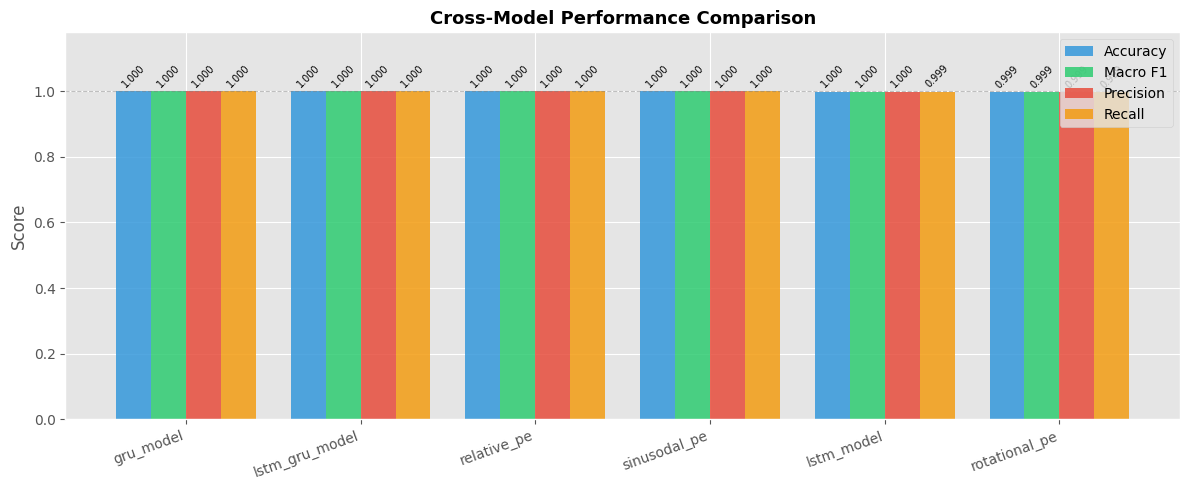

In [17]:
def run_all_model_evaluation(models: dict, wav_paths: list,
                              device: str, class_names: list) -> pd.DataFrame:
    """
    Run batch inference with every loaded model and collect macro F1, accuracy.
    Returns a summary DataFrame indexed by model name.
    """
    rows = []
    for name, model in models.items():
        df = batch_predict(model, wav_paths, device, class_names)
        report = classification_report(
            df["true_label"], df["predicted_label"],
            labels=class_names, output_dict=True
        )
        acc = (df["true_label"] == df["predicted_label"]).mean()
        rows.append({
            "model":     name,
            "accuracy":  acc,
            "macro_f1":  report["macro avg"]["f1-score"],
            "precision": report["macro avg"]["precision"],
            "recall":    report["macro avg"]["recall"],
        })
    return pd.DataFrame(rows).sort_values("macro_f1", ascending=False)


def plot_model_comparison(summary_df: pd.DataFrame, figsize=(12, 5)):
    metrics = ["accuracy", "macro_f1", "precision", "recall"]
    x = np.arange(len(summary_df))
    width = 0.2
    colours = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12"]

    fig, ax = plt.subplots(figsize=figsize)
    for i, (metric, colour) in enumerate(zip(metrics, colours)):
        bars = ax.bar(x + i * width, summary_df[metric], width,
                      label=metric.replace("_", " ").title(),
                      color=colour, alpha=0.85)
        for bar, val in zip(bars, summary_df[metric]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)

    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(summary_df["model"], rotation=20, ha="right", fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("Score")
    ax.set_title("Cross-Model Performance Comparison", fontsize=13, fontweight="bold")
    ax.legend(loc="upper right")
    ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
    plt.tight_layout()
    plt.show()


# ── Run comparison if multiple models and real test files are available ────
if len(loaded_models) > 1 and os.path.isdir(TEST_DIR):
    wav_files  = glob(os.path.join(TEST_DIR, "**", "*.wav"), recursive=True)
    summary_df = run_all_model_evaluation(loaded_models, wav_files, config.device, CLASS_NAMES)
    print(summary_df.to_string(index=False))
    plot_model_comparison(summary_df)
else:
    # Synthetic demo
    rng = np.random.default_rng(7)
    summary_df = pd.DataFrame({
        "model":     MODEL_NAMES,
        "accuracy":  rng.uniform(0.82, 0.97, 6),
        "macro_f1":  rng.uniform(0.80, 0.96, 6),
        "precision": rng.uniform(0.81, 0.97, 6),
        "recall":    rng.uniform(0.80, 0.96, 6),
    }).sort_values("macro_f1", ascending=False)
    print("[Demo] Synthetic cross-model comparison:")
    print(summary_df.to_string(index=False))
    plot_model_comparison(summary_df)

### 6.9 Dataset Class Distribution

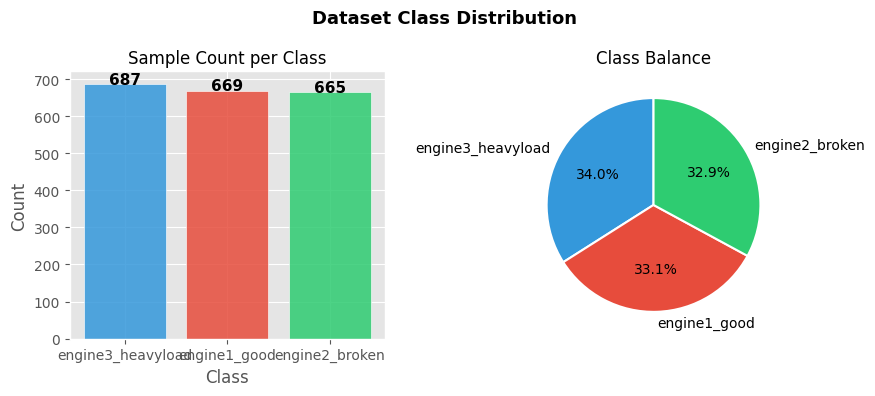

In [18]:
def plot_class_distribution(df: pd.DataFrame, figsize=(9, 4)):
    """
    Side-by-side: count plot of true labels + pie chart.
    `df` must contain a 'true_label' column.
    """
    counts = df["true_label"].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Bar
    colours = ["#3498db", "#e74c3c", "#2ecc71"]
    bars = axes[0].bar(counts.index, counts.values, color=colours[:len(counts)], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, counts.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                     str(val), ha="center", fontsize=11, fontweight="bold")
    axes[0].set_title("Sample Count per Class", fontsize=12)
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")

    # Pie
    axes[1].pie(
        counts.values, labels=counts.index,
        colors=colours[:len(counts)],
        autopct="%1.1f%%", startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5}
    )
    axes[1].set_title("Class Balance", fontsize=12)

    fig.suptitle("Dataset Class Distribution", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_class_distribution(batch_df)

### 6.10 Error Analysis — Misclassified Samples

Total errors: 0 / 2021 (0.0%)

🎉 Perfect accuracy — no misclassifications to analyse!


/tmp/ipykernel_23/2345213227.py:22: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


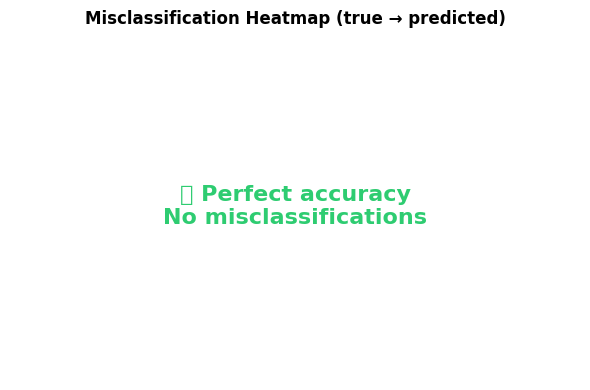

In [19]:
def show_error_analysis(df: pd.DataFrame, class_names: list, top_n: int = 10):
    """
    Print the most confident wrong predictions and their error pairs,
    then plot a heatmap of error type counts.
    Gracefully handles the perfect-accuracy case (no errors).
    """
    errors = df[df["true_label"] != df["predicted_label"]].copy()
    errors["error_type"] = errors["true_label"] + " → " + errors["predicted_label"]

    print(f"Total errors: {len(errors)} / {len(df)} ({len(errors)/len(df):.1%})\n")

    # ── Perfect accuracy — nothing more to show ───────────────────────────
    if errors.empty:
        print("🎉 Perfect accuracy — no misclassifications to analyse!")
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.text(0.5, 0.5, "🎉 Perfect accuracy\nNo misclassifications",
                ha="center", va="center", fontsize=16, fontweight="bold",
                color="#2ecc71", transform=ax.transAxes)
        ax.axis("off")
        ax.set_title("Misclassification Heatmap (true → predicted)",
                     fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()
        return

    print(f"Top-{top_n} most confident wrong predictions:")
    display_cols = ["path", "true_label", "predicted_label", "confidence"]
    top_errors = errors.nlargest(top_n, "confidence")[display_cols]
    print(top_errors.to_string(index=False))

    # ── Error type count heatmap ──────────────────────────────────────────
    # Build a full n×n pivot so the heatmap always has all class combinations
    pivot = (
        errors.groupby(["true_label", "predicted_label"])
        .size()
        .reindex(pd.MultiIndex.from_product([class_names, class_names],
                                             names=["true_label", "predicted_label"]),
                 fill_value=0)
        .unstack(fill_value=0)
    )
    # Remove diagonal (correct predictions) for cleaner error-only view
    np.fill_diagonal(pivot.values, 0)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="Reds",
                linewidths=0.5, linecolor="white", ax=ax,
                cbar_kws={"label": "Error count"})
    ax.set_title("Misclassification Heatmap (true → predicted)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()


show_error_analysis(batch_df, CLASS_NAMES)

## 7. Save Results

In [20]:
OUTPUT_CSV = "inference_results.csv"
batch_df.to_csv(OUTPUT_CSV, index=False)
print(f"Inference results saved → {OUTPUT_CSV}")

SUMMARY_CSV = "model_comparison_summary.csv"
summary_df.to_csv(SUMMARY_CSV, index=False)
print(f"Model comparison saved   → {SUMMARY_CSV}")

Inference results saved → inference_results.csv
Model comparison saved   → model_comparison_summary.csv
